# MAP/PH/1: why correlated arrivals matter

Classic queueing models assume *renewal* arrivals: interarrival times are independent.
Real traffic (packets, requests, calls) is usually **bursty**: a busy period brings many
arrivals in a row. The Markovian Arrival Process (MAP) captures this with two matrices
$(D_0, D_1)$, and the MAP/PH/1 queue is solved exactly by the QBD method
(`most_queue.theory.matrix`).

The punchline of this notebook: **two arrival processes with identical mean and CV of
interarrival times can produce vastly different queues** — the difference is the
autocorrelation, which renewal-based models simply cannot see.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from most_queue.random.map_ph import MAP, PHDistribution
from most_queue.random.distributions import H2Distribution
from most_queue.theory.matrix.map_ph1 import MapPh1Calc

UTILIZATION = 0.7

def mmpp_family(switch_rate):
    """Two-state MMPP: fast/slow Poisson phases; slower switching = stronger correlation."""
    q = np.array([[-switch_rate, switch_rate], [1.5 * switch_rate, -1.5 * switch_rate]])
    return MAP.mmpp([2.0, 0.4], q)

switch_rates = [20.0, 5.0, 1.0, 0.3, 0.1, 0.05]
for sr in switch_rates:
    m = mmpp_family(sr)
    mom = MAP.calc_theory_moments(m, 2)
    cv = np.sqrt(mom[1] - mom[0] ** 2) / mom[0]
    print(f"switch_rate={sr:5.2f}: mean={mom[0]:.3f}, cv={cv:.3f}, lag-1 corr={MAP.lag_correlation(m, 1):.4f}")

switch_rate=20.00: mean=0.735, cv=1.009, lag-1 corr=0.0001
switch_rate= 5.00: mean=0.735, cv=1.034, lag-1 corr=0.0015
switch_rate= 1.00: mean=0.735, cv=1.137, lag-1 corr=0.0216
switch_rate= 0.30: mean=0.735, cv=1.294, lag-1 corr=0.0886
switch_rate= 0.10: mean=0.735, cv=1.441, lag-1 corr=0.1820
switch_rate= 0.05: mean=0.735, cv=1.506, lag-1 corr=0.2305


The switching rate barely changes the mean and CV, but the lag-1 autocorrelation grows
as switching slows down. Now compute the exact mean waiting time for each case and for
a **renewal** process with the same mean/CV (an H₂ renewal MAP):

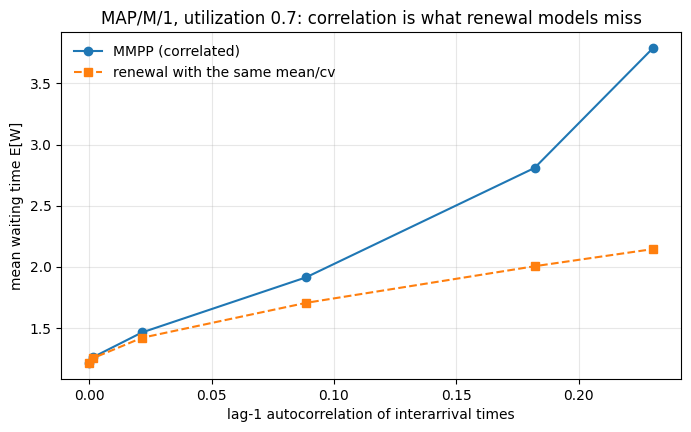

In [2]:
def mean_wait(map_params):
    lam = MAP.arrival_rate(map_params)
    calc = MapPh1Calc()
    calc.set_sources(map_params)
    calc.set_servers(PHDistribution.from_exp(lam / UTILIZATION))
    return calc.run().w[0]

corrs, waits, waits_renewal = [], [], []
for sr in switch_rates:
    m = mmpp_family(sr)
    corrs.append(MAP.lag_correlation(m, 1))
    waits.append(mean_wait(m))
    mom = MAP.calc_theory_moments(m, 2)
    cv = float(np.sqrt(mom[1] - mom[0] ** 2) / mom[0])
    h2 = H2Distribution.get_params_by_mean_and_cv(mom[0], cv)
    waits_renewal.append(mean_wait(MAP.from_ph_renewal(PHDistribution.from_h2(h2))))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(corrs, waits, "o-", label="MMPP (correlated)")
ax.plot(corrs, waits_renewal, "s--", label="renewal with the same mean/cv")
ax.set_xlabel("lag-1 autocorrelation of interarrival times")
ax.set_ylabel("mean waiting time E[W]")
ax.set_title(f"MAP/M/1, utilization {UTILIZATION}: correlation is what renewal models miss")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.show()

## Cross-check with simulation

The simulator accepts MAP sources and PH servers directly:

In [3]:
from most_queue.sim.base import QsSim

m = mmpp_family(0.3)
lam = MAP.arrival_rate(m)
ph = PHDistribution.from_exp(lam / UTILIZATION)

sim = QsSim(1, verbose=False)
sim.set_sources(m, "MAP")
sim.set_servers(ph, "PH")
sim_res = sim.run(200_000)

print(f"E[W]: QBD theory {mean_wait(m):.3f} vs simulation {sim_res.w[0]:.3f}")

Start simulation


Job served:    | 1/100 [00:00<00:17,  5.72it/s]2000/200000:   1%|          | 1/100 [00:00<00:17,  5.72it/s]2000/200000:   2%|▏         | 2/100 [00:00<00:15,  6.25it/s]4000/200000:   2%|▏         | 2/100 [00:00<00:15,  6.25it/s]4000/200000:   3%|▎         | 3/100 [00:00<00:16,  6.00it/s]6000/200000:   3%|▎         | 3/100 [00:00<00:16,  6.00it/s]6000/200000:   4%|▍         | 4/100 [00:00<00:20,  4.77it/s]8000/200000:   4%|▍         | 4/100 [00:00<00:20,  4.77it/s]8000/200000:   5%|▌         | 5/100 [00:00<00:16,  5.81it/s]10000/200000:   5%|▌         | 5/100 [00:00<00:16,  5.81it/s]12000/200000:   6%|▌         | 6/100 [00:00<00:16,  5.81it/s]12000/200000:   7%|▋         | 7/100 [00:01<00:12,  7.54it/s]14000/200000:   7%|▋         | 7/100 [00:01<00:12,  7.54it/s]14000/200000:   8%|▊         | 8/100 [00:01<00:11,  7.99it/s]16000/200000:   8%|▊         | 8/100 [00:01<00:11,  7.99it/s]16000/200000:   9%|▉         | 9/100 [00:01<00:10,  8.34it/s]18000/200000:   9%|▉         | 9/100 [00:01<00

Simulation is finished

E[W]: QBD theory 1.914 vs simulation 1.923


## Takeaways

1. At the same utilization, mean and CV, the mean wait grows **several-fold** as arrival
   correlation increases — burstiness is a first-class citizen of performance analysis.
2. The QBD solution is exact and fast (matrix-geometric tail), and every result can be
   cross-checked by simulation with the same `MAPParams`/`PHParams` objects.
3. `MPh1Calc` / `PhPh1Calc` cover the uncorrelated special cases and reproduce
   Pollaczek–Khinchine and GI/M/1 exactly (see `tests/test_map_ph1.py`).